In [4]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import torch

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# Dataset
dataset = ImageFolder(root="../data_lionel/train_dataset", transform=transform)

print("Classes:", dataset.classes)
print("Class to index:", dataset.class_to_idx)
print("Number of images:", len(dataset))

Device: cuda
Classes: ['diseased', 'healthy']
Class to index: {'diseased': 0, 'healthy': 1}
Number of images: 3276


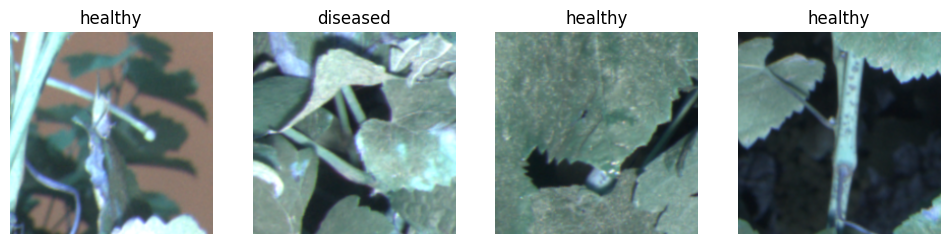

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(loader):
    imgs, labels = next(iter(loader))
    fig, axes = plt.subplots(1,4, figsize=(12,4))
    
    for i in range(4):
        img = imgs[i].permute(1,2,0)
        axes[i].imshow(img)
        axes[i].set_title(dataset.classes[labels[i]])
        axes[i].axis("off")
        
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)
show_images(train_loader)

In [ ]:
# simple split 
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

train_idx, val_idx = train_test_split(
    range(len(dataset)), test_size=0.2, shuffle=True
)

train_loader = DataLoader(Subset(dataset, train_idx),
                          batch_size=32,
                          shuffle=True)

val_loader = DataLoader(Subset(dataset, val_idx),
                        batch_size=32,
                        shuffle=False)

In [8]:
# model initialization
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights="DEFAULT")

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 2)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/adjalil/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 45.0MB/s]


In [10]:
# train
for epoch in range(10):
    model.train()
    running_loss = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1} - Loss: {running_loss/len(train_loader):.4f}")

Epoch 1 - Loss: 0.2944
Epoch 2 - Loss: 0.2766
Epoch 3 - Loss: 0.2359
Epoch 4 - Loss: 0.2318
Epoch 5 - Loss: 0.1869
Epoch 6 - Loss: 0.1831
Epoch 7 - Loss: 0.1431
Epoch 8 - Loss: 0.1385
Epoch 9 - Loss: 0.0891
Epoch 10 - Loss: 0.1227


In [11]:
# validation
model.eval()
correct = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()

acc = correct / len(val_loader.dataset)
print("Validation Accuracy:", acc)

Validation Accuracy: 0.823170731707317
